# Feature Engineering Testing v2

Jalankan setelah Combination dan Training v2 selesai. Notebook ini memuat konfigurasi yang sudah dibekukan, mengekstrak fitur official test dengan checkpoint CNN v1 dalam mode inferensi, lalu menghitung prediksi dan metrik sekali. Official test telah pernah dievaluasi pada eksperimen v1; hasil v2 dilaporkan sebagai **post-exposure testing**. Tidak ada fitting, GridSearchCV, atau pemilihan parameter berdasarkan test.

## 1. Konfigurasi

Tetapkan sumber checkpoint v1, artefak v2, dan seed. GPU menggunakan memory growth.

In [1]:
from pathlib import Path
import gc
import hashlib
import json
import os
import time

import joblib
import numpy as np
import tensorflow as tf
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import Normalizer, StandardScaler

SEED = 30092026
SOURCE_RUN = "cifar10_7fitur_v1"
RUN_ID = "cifar10_7fitur_v2"
ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / RUN_ID / "fusion"
VARIANTS = ("rgb", "avg", "ntsc")
BLOCK_NAMES = ("rgb", "avg", "ntsc", "hog", "lbp", "hsv", "rgb_stats")
BATCH_SIZE = 128
TEST_STARTED = time.perf_counter()
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

I0000 00:00:1791497633.535716  227945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791497633.572627  227945 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791497634.509209  227945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Kelas preprocessing untuk memuat model

Definisi `transform` memuat scaler yang sudah di-fit dan disimpan oleh Training. Notebook Testing tidak mendefinisikan atau menjalankan fitting.


In [2]:
class GroupPreprocessor(TransformerMixin, BaseEstimator):
    def __init__(self, boundaries, weights, global_l2=True):
        self.boundaries = boundaries
        self.weights = weights
        self.global_l2 = global_l2

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        if X.shape[1] != self.boundaries[-1]:
            raise ValueError("Dimensi fitur berbeda dari saat fitting")
        parts = []
        for scaler, left, right, weight in zip(
                self.scalers_, self.boundaries[:-1], self.boundaries[1:], self.weights):
            scaled = scaler.transform(X[:, left:right]).astype(np.float32)
            parts.append(Normalizer().transform(scaled) * np.float32(weight))
        result = np.concatenate(parts, axis=1)
        if self.global_l2:
            result = Normalizer().transform(result)
        if not np.isfinite(result).all():
            raise ValueError("Preprocessing menghasilkan NaN atau inf")
        return result


## 3. Validasi seleksi dan model final

Periksa bahwa file seleksi telah dibekukan, model di-fit pada 50.000 training, dan hash checkpoint serta arsip kandidat terpilih masih sesuai. Jika ada perbedaan, hentikan pengujian.

In [3]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

selection_path = OUT / "laporan" / "selection.json"
manifest_path = OUT / "laporan" / "combination_manifest.json"
model_path = OUT / "model" / "fusion_svm_final.joblib"
for path in (selection_path, manifest_path, model_path):
    if not path.exists():
        raise FileNotFoundError(f"Artefak wajib belum tersedia: {path}")
selection = json.loads(selection_path.read_text(encoding="utf-8"))
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
payload = joblib.load(model_path)
rep = selection["representation"]
archive_path = OUT / "fitur" / f"train_combined_{rep}.npz"
checks = [selection["run_id"] == RUN_ID,
          manifest["run_id"] == RUN_ID,
          manifest["source_run"] == SOURCE_RUN,
          selection["model_hashes"] == manifest["model_hashes"],
          selection["archive_sha256"] == manifest["archive_sha256"][rep],
          selection["boundaries"] == manifest["boundaries"][rep],
          selection["preprocessing_version"] == manifest["preprocessing_version"],
          payload["run_id"] == RUN_ID,
          payload["selection_sha256"] == sha256_file(selection_path),
          payload["archive_sha256"] == selection["archive_sha256"],
          payload["representation"] == rep,
          payload["boundaries"] == selection["boundaries"],
          payload["model_hashes"] == selection["model_hashes"],
          payload["split_hash"] == selection["split_hash"],
          payload["preprocessing_version"] == selection["preprocessing_version"],
          payload["training_count"] == 50000,
          len(selection["boundaries"]) == 8,
          len(selection["weights"]) == 7,
          rep in ("A", "B", "C")]
if not all(checks):
    raise ValueError("Model final, seleksi, dan manifest tidak kompatibel")
if not archive_path.exists() or sha256_file(archive_path) != selection["archive_sha256"]:
    raise ValueError("Arsip training terpilih berubah")
for variant, expected_hash in zip(VARIANTS, selection["model_hashes"]):
    cnn_path = ROOT / "outputs" / SOURCE_RUN / variant / "model" / "cnn.keras"
    if sha256_file(cnn_path) != expected_hash:
        raise ValueError(f"Checkpoint CNN {variant} berubah")
svm = payload["pipeline"]
if svm.named_steps["svc"].n_features_in_ != selection["boundaries"][-1]:
    raise ValueError("Jumlah fitur SVM tidak sesuai")
print("Model final dan provenance valid:", rep, selection["boundaries"][-1])

Model final dan provenance valid: B 2173


## 4. Data official test

Dataset test dibuka setelah konfigurasi final lolos validasi. Label dipakai hanya untuk perhitungan metrik setelah prediksi.

In [4]:
from tensorflow.keras.datasets import cifar10

(_, _), (x_test, y_test) = cifar10.load_data()
y_test = y_test.ravel().astype(np.int64)
if x_test.shape != (10000, 32, 32, 3) or y_test.shape != (10000,):
    raise ValueError("Ukuran official test tidak sesuai")
print("Official test:", x_test.shape)

Official test: (10000, 32, 32, 3)


## 5. Rumus kanal input CNN

Rumus sama dengan Training dan Combination. Flip bersifat deterministik dan hanya dipakai untuk representasi B atau C.

In [5]:
def prepare_images(x, variant):
    x = np.asarray(x, dtype=np.float32) / 255.0
    if variant == "rgb":
        return x
    if variant == "avg":
        return np.mean(x, axis=-1, keepdims=True, dtype=np.float32)
    if variant == "ntsc":
        return np.sum(x * np.array([0.299, 0.587, 0.114], np.float32),
                      axis=-1, keepdims=True)
    raise ValueError(f"Varian tidak dikenal: {variant}")

## 6. Ekstraksi CNN official test

Tiga CNN dipakai bergantian agar VRAM 6 GB tetap terkendali. A mengambil Dense asli; B mengambil rata-rata Dense asli dan flip; C mengambil rata-rata pooling asli dan flip. Setiap panggilan memakai `training=False`.

In [6]:
def extract_test(images, variant, cnn_path, representation, batch_size=BATCH_SIZE):
    cnn = tf.keras.models.load_model(cnn_path, compile=False)
    layer_name = "global_average_pooling2d" if representation == "C" else "embedding"
    extractor = tf.keras.Model(cnn.input, cnn.get_layer(layer_name).output)
    dim = 256 if representation == "C" else 512
    if extractor.output.shape[-1] != dim:
        raise ValueError(f"Layer {layer_name} pada {variant} berdimensi salah")
    result = np.empty((len(images), dim), np.float32)
    interval = max(1, int(np.ceil(len(images) / batch_size)) // 20)
    for number, begin in enumerate(range(0, len(images), batch_size), 1):
        end = min(begin + batch_size, len(images))
        batch = prepare_images(images[begin:end], variant)
        original_view = extractor(batch, training=False).numpy()
        if representation == "A":
            result[begin:end] = original_view
        else:
            flipped = np.ascontiguousarray(batch[:, :, ::-1, :])
            flipped_view = extractor(flipped, training=False).numpy()
            result[begin:end] = (original_view + flipped_view) * np.float32(0.5)
        if number % interval == 0 or end == len(images):
            print(f"{variant}: {end}/{len(images)}", flush=True)
    if not np.isfinite(result).all():
        raise ValueError(f"Fitur test {variant} mengandung NaN/inf")
    del extractor, cnn
    tf.keras.backend.clear_session()
    gc.collect()
    return result

cnn_test = {}
for variant in VARIANTS:
    cnn_path = ROOT / "outputs" / SOURCE_RUN / variant / "model" / "cnn.keras"
    cnn_test[variant] = extract_test(x_test, variant, cnn_path, rep)
print({key: value.shape for key, value in cnn_test.items()})

I0000 00:00:1791497637.358882  227945 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4139 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1791497638.415386  227945 cuda_dnn.cc:461] Loaded cuDNN version 92600


rgb: 384/10000
rgb: 768/10000
rgb: 1152/10000
rgb: 1536/10000
rgb: 1920/10000
rgb: 2304/10000
rgb: 2688/10000
rgb: 3072/10000
rgb: 3456/10000
rgb: 3840/10000
rgb: 4224/10000
rgb: 4608/10000
rgb: 4992/10000
rgb: 5376/10000
rgb: 5760/10000
rgb: 6144/10000
rgb: 6528/10000
rgb: 6912/10000
rgb: 7296/10000
rgb: 7680/10000
rgb: 8064/10000
rgb: 8448/10000
rgb: 8832/10000
rgb: 9216/10000
rgb: 9600/10000
rgb: 9984/10000
rgb: 10000/10000
avg: 384/10000
avg: 768/10000
avg: 1152/10000
avg: 1536/10000
avg: 1920/10000
avg: 2304/10000
avg: 2688/10000
avg: 3072/10000
avg: 3456/10000
avg: 3840/10000
avg: 4224/10000
avg: 4608/10000
avg: 4992/10000
avg: 5376/10000
avg: 5760/10000
avg: 6144/10000
avg: 6528/10000
avg: 6912/10000
avg: 7296/10000
avg: 7680/10000
avg: 8064/10000
avg: 8448/10000
avg: 8832/10000
avg: 9216/10000
avg: 9600/10000
avg: 9984/10000
avg: 10000/10000
ntsc: 384/10000
ntsc: 768/10000
ntsc: 1152/10000
ntsc: 1536/10000
ntsc: 1920/10000
ntsc: 2304/10000
ntsc: 2688/10000
ntsc: 3072/10000
ntsc

## 7. Definisi empat descriptor

HOG 324, LBP 256, HSV 48, dan statistik RGB 9 dihitung dengan rumus v1 yang sama. Histogram dan statistik tidak memiliki parameter yang dipelajari dari official test.

In [7]:
def handcrafted_descriptors(x, batch_size=128, verbose=1):
    # HOG: 9 orientasi unsigned, cell 8x8, block 2x2, L2 per block.
    # LBP: 8 tetangga radius 1, histogram 256 kode.
    # HSV: 16 bin per kanal. Statistik RGB: mean, std, skewness per kanal.
    import matplotlib.colors as mcolors
    outputs = {k: [] for k in ("hog", "lbp", "hsv", "rgb_stats")}
    total_batches = int(np.ceil(len(x) / batch_size))
    progress_interval = max(1, total_batches // 20)
    for begin in range(0, len(x), batch_size):
        rgb = np.asarray(x[begin:begin+batch_size], dtype=np.float32) / 255.0
        gray = np.sum(rgb * np.array([0.299, 0.587, 0.114], np.float32), axis=-1)
        gy, gx = np.gradient(gray, axis=(1, 2))
        magnitude = np.sqrt(gx*gx + gy*gy)
        orientation = np.mod(np.arctan2(gy, gx) * (180.0 / np.pi), 180.0)
        bins = np.minimum((orientation / 20.0).astype(np.int32), 8)
        cell_hist = np.zeros((len(rgb), 4, 4, 9), dtype=np.float32)
        for row in range(4):
            for col in range(4):
                b = bins[:, row*8:(row+1)*8, col*8:(col+1)*8]
                m = magnitude[:, row*8:(row+1)*8, col*8:(col+1)*8]
                for angle in range(9):
                    cell_hist[:, row, col, angle] = np.sum(m * (b == angle), axis=(1, 2))
        blocks = []
        for row in range(3):
            for col in range(3):
                block = cell_hist[:, row:row+2, col:col+2, :].reshape(len(rgb), -1)
                denominator = np.maximum(
                    np.linalg.norm(block, axis=1, keepdims=True), 1e-8
                )
                blocks.append(block / denominator)
        outputs["hog"].append(np.concatenate(blocks, axis=1))
        padded = np.pad(gray, ((0, 0), (1, 1), (1, 1)), mode="edge")
        lbp = np.zeros(gray.shape, dtype=np.uint8)
        offsets = [(-1,-1), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1)]
        for bit, (dy, dx) in enumerate(offsets):
            neighbor = padded[:, 1+dy:33+dy, 1+dx:33+dx]
            lbp |= (neighbor >= gray).astype(np.uint8) << bit
        hist = np.zeros((len(rgb), 256), dtype=np.float32)
        np.add.at(hist, (np.repeat(np.arange(len(rgb)), 1024), lbp.reshape(-1)), 1)
        outputs["lbp"].append(hist / 1024.0)
        hsv = mcolors.rgb_to_hsv(rgb)
        hsv_hist = np.zeros((len(rgb), 3, 16), dtype=np.float32)
        for channel in range(3):
            hsv_bin = np.minimum((hsv[..., channel] * 16).astype(np.int32), 15)
            np.add.at(hsv_hist[:, channel, :],
                      (np.repeat(np.arange(len(rgb)), 1024), hsv_bin.reshape(-1)), 1)
        outputs["hsv"].append(hsv_hist.reshape(len(rgb), -1) / 1024.0)
        flat = rgb.reshape(len(rgb), -1, 3)
        mean = flat.mean(axis=1)
        std = flat.std(axis=1)
        skew = np.mean(((flat - mean[:, None, :]) / np.maximum(std[:, None, :], 1e-6)) ** 3, axis=1)
        outputs["rgb_stats"].append(np.concatenate((mean, std, skew), axis=1))
        batch_number = begin // batch_size + 1
        if verbose == 1 and (
            batch_number % progress_interval == 0
            or batch_number == total_batches
        ):
            processed = min(begin + batch_size, len(x))
            print(f"Descriptor: {processed}/{len(x)} gambar", flush=True)
    result = {key: np.concatenate(parts).astype(np.float32) for key, parts in outputs.items()}
    assert [result[k].shape[1] for k in ("hog", "lbp", "hsv", "rgb_stats")] == [324, 256, 48, 9]
    assert all(np.isfinite(value).all() for value in result.values())
    return result

## 8. Hitung empat descriptor official test

Setiap gambar diproses satu kali, dengan progres per batch. Fitur dibuat tanpa fitting.

In [8]:
started = time.perf_counter()
handcrafted_test = handcrafted_descriptors(x_test, batch_size=BATCH_SIZE, verbose=1)
print("Descriptor selesai dalam", round(time.perf_counter() - started, 1), "detik")
print({key: value.shape for key, value in handcrafted_test.items()})

Descriptor: 384/10000 gambar
Descriptor: 768/10000 gambar
Descriptor: 1152/10000 gambar
Descriptor: 1536/10000 gambar
Descriptor: 1920/10000 gambar
Descriptor: 2304/10000 gambar
Descriptor: 2688/10000 gambar
Descriptor: 3072/10000 gambar
Descriptor: 3456/10000 gambar
Descriptor: 3840/10000 gambar
Descriptor: 4224/10000 gambar
Descriptor: 4608/10000 gambar
Descriptor: 4992/10000 gambar
Descriptor: 5376/10000 gambar
Descriptor: 5760/10000 gambar
Descriptor: 6144/10000 gambar
Descriptor: 6528/10000 gambar
Descriptor: 6912/10000 gambar
Descriptor: 7296/10000 gambar
Descriptor: 7680/10000 gambar
Descriptor: 8064/10000 gambar
Descriptor: 8448/10000 gambar
Descriptor: 8832/10000 gambar
Descriptor: 9216/10000 gambar
Descriptor: 9600/10000 gambar
Descriptor: 9984/10000 gambar
Descriptor: 10000/10000 gambar
Descriptor selesai dalam 3.5 detik
{'hog': (10000, 324), 'lbp': (10000, 256), 'hsv': (10000, 48), 'rgb_stats': (10000, 9)}


## 9. Gabungkan dan simpan fitur test

Urutan serta dimensi blok diperiksa terhadap seleksi final. Arsip test v2 menyimpan indeks, label, split, representasi, versi preprocessing, dan hash model untuk audit.

In [9]:
blocks = [cnn_test[key] for key in VARIANTS]
blocks += [handcrafted_test[key] for key in ("hog", "lbp", "hsv", "rgb_stats")]
boundaries = np.cumsum([0] + [block.shape[1] for block in blocks]).tolist()
if boundaries != selection["boundaries"]:
    raise ValueError(f"Batas blok test berbeda: {boundaries}")
combined_test = np.concatenate(blocks, axis=1).astype(np.float32)
if combined_test.shape != (10000, boundaries[-1]) or not np.isfinite(combined_test).all():
    raise ValueError("Fitur official test tidak valid")
test_archive_path = OUT / "fitur" / "test_combined_final.npz"
if test_archive_path.exists():
    with np.load(test_archive_path, allow_pickle=False) as archive:
        if (str(archive["selection_sha256"]) != sha256_file(selection_path)
                or str(archive["representation"]) != rep
                or not np.array_equal(archive["features"], combined_test)):
            raise ValueError("Arsip test yang ada berbeda; jangan timpa hasil eksperimen")
else:
    temporary = test_archive_path.with_suffix(".npz.tmp")
    with open(temporary, "wb") as stream:
        np.savez_compressed(stream, features=combined_test, y=y_test,
                            indices=np.arange(10000), run_id=RUN_ID,
                            representation=rep, split_hash=selection["split_hash"],
                            preprocessing_version=selection["preprocessing_version"],
                            block_names=np.array(BLOCK_NAMES), boundaries=np.array(boundaries),
                            model_hashes=np.array(selection["model_hashes"]),
                            selection_sha256=sha256_file(selection_path))
    os.replace(temporary, test_archive_path)
print("Arsip test:", test_archive_path)

Arsip test: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-after-uts/outputs/cifar10_7fitur_v2/fusion/fitur/test_combined_final.npz


## 10. Prediksi official test

Model final yang sudah dibekukan menghasilkan satu prediksi per sampel. Tidak ada pencarian atau pemilihan konfigurasi dalam cell ini.

In [10]:
started = time.perf_counter()
pred = svm.predict(combined_test)
if pred.shape != y_test.shape:
    raise ValueError("Jumlah prediksi berbeda dari jumlah sampel test")
print("Prediksi selesai dalam", round(time.perf_counter() - started, 1), "detik")

Prediksi selesai dalam 21.6 detik


## 11. Metrik, prediksi, dan status target

Simpan accuracy, macro-F1, classification report, confusion matrix, dan prediksi berindeks. Target tercapai jika sekurangnya 9.500 dari 10.000 label benar. Bandingkan dengan hasil v1 93,14% sebagai konteks; karena v1 sudah memakai official test, hasil v2 berstatus post-exposure.

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
v1_metrics_path = ROOT / "outputs" / SOURCE_RUN / "fusion" / "laporan" / "test_metrics.json"
v1_metrics = json.loads(v1_metrics_path.read_text(encoding="utf-8"))
correct = int(np.sum(pred == y_test))
accuracy = float(accuracy_score(y_test, pred))
metrics = {
    "run_id": RUN_ID, "representation": rep,
    "selection_sha256": sha256_file(selection_path),
    "model_sha256": sha256_file(model_path),
    "test_archive_sha256": sha256_file(test_archive_path),
    "correct": correct, "total": len(y_test),
    "accuracy": accuracy,
    "macro_f1": float(f1_score(y_test, pred, average="macro")),
    "classification_report": classification_report(
        y_test, pred, target_names=CLASS_NAMES, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    "v1_official_test_accuracy": float(v1_metrics["accuracy"]),
    "v1_three_embeddings_official_test_accuracy": float(
        v1_metrics["baseline_accuracy"]),
    "accuracy_delta_from_v1": accuracy - float(v1_metrics["accuracy"]),
    "target_accuracy": 0.95,
    "target_status": "tercapai" if correct >= 9500 else "belum tercapai",
    "post_exposure_testing": True,
    "test_seconds": float(time.perf_counter() - TEST_STARTED),
}
metrics_path = OUT / "laporan" / "test_metrics.json"
if metrics_path.exists():
    previous = json.loads(metrics_path.read_text(encoding="utf-8"))
    if previous["selection_sha256"] != metrics["selection_sha256"]:
        raise ValueError("Laporan test yang ada berasal dari seleksi lain")
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
np.savez_compressed(OUT / "laporan" / "test_predictions.npz",
                    indices=np.arange(10000), y_true=y_test, y_pred=pred,
                    selection_sha256=metrics["selection_sha256"])
print(classification_report(y_test, pred, target_names=CLASS_NAMES))
print("Accuracy:", accuracy, "v1:", metrics["v1_official_test_accuracy"],
      "target:", metrics["target_status"], "(post-exposure)")
print("Waktu testing:", round(metrics["test_seconds"] / 60, 1), "menit")

              precision    recall  f1-score   support

    airplane       0.93      0.95      0.94      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.91      0.91      0.91      1000
         cat       0.87      0.86      0.86      1000
        deer       0.92      0.94      0.93      1000
         dog       0.89      0.89      0.89      1000
        frog       0.95      0.95      0.95      1000
       horse       0.96      0.96      0.96      1000
        ship       0.96      0.95      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Accuracy: 0.9326 v1: 0.9314 target: belum tercapai (post-exposure)
Waktu testing: 1.0 menit


## 12. Grafik confusion matrix

Simpan visualisasi kelas dari prediksi final yang sama dengan laporan JSON.

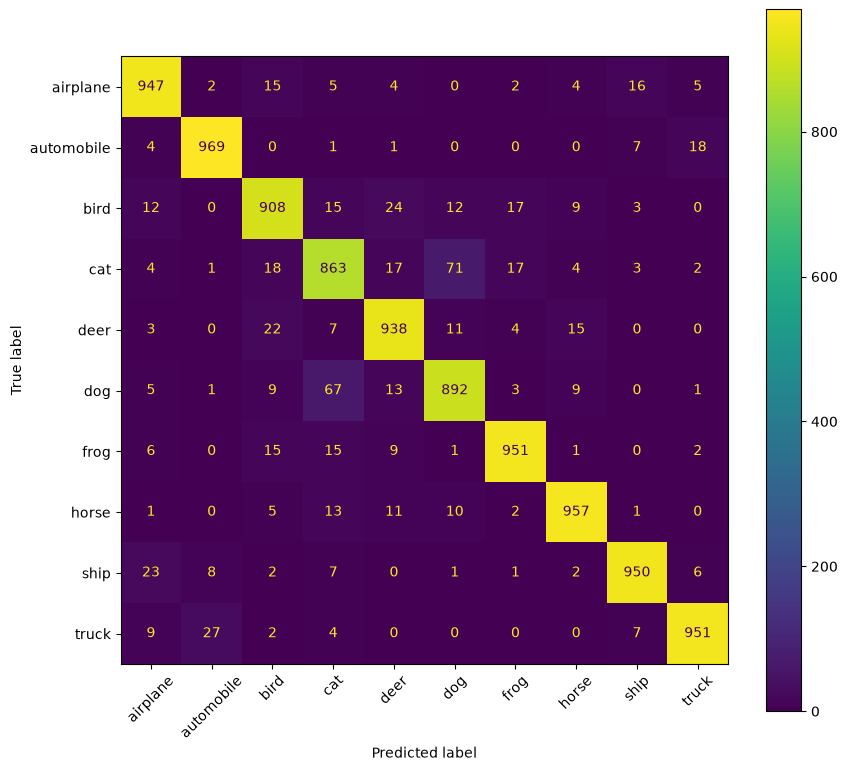

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

display = ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=CLASS_NAMES, xticks_rotation=45
)
display.figure_.set_size_inches(9, 8)
display.figure_.tight_layout()
display.figure_.savefig(OUT / "laporan" / "confusion_matrix.png", dpi=150)
plt.show()